# Pneumonia-CNN Model
--------------------

## Objectives of the Pneumonia Detection Model

The primary objectives of this project are:

1. **Early Detection of Pneumonia**:
    - Develop a robust Convolutional Neural Network (CNN) model to classify chest X-ray images into two categories: NORMAL and PNEUMONIA.
    - Enable early diagnosis to assist healthcare professionals in providing timely treatment.

2. **Data Augmentation**:
    - Enhance the dataset by applying transformations such as flipping, rotation, zooming, and brightness adjustments to improve the model's generalization capabilities.

3. **Model Optimization**:
    - Use techniques like dropout layers and early stopping to prevent overfitting and improve the model's performance on unseen data.

4. **Evaluation and Visualization**:
    - Evaluate the model's performance on a separate test dataset and visualize predictions to understand its strengths and weaknesses.

5. **Future Improvements**:
    - Plan to incorporate transfer learning using pre-trained models like MobileNetV2 to achieve higher accuracy and efficiency.

# Importing data

In [2]:
import kagglehub
import os
import numpy
import keras
from tensorflow.keras.utils import image_dataset_from_directory
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import layers

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

print(path)

train_dir = os.path.join(path, 'chest_xray', 'train')
test_dir = os.path.join(path, 'chest_xray', 'test')
val_dir = os.path.join(path, 'chest_xray', 'val')

print('Train dir:',train_dir)


/opt/anaconda3/envs/keras/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/jafarjafarov/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
/Users/jafarjafarov/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
Train dir: /Users/jafarjafarov/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/train


### Preparing the Datasets

In this step, we prepared the training, validation, and test datasets using the `image_dataset_from_directory` function from TensorFlow. The datasets were created with the following configurations:

1. **Image Dimensions**:
    - All images were resized to a uniform size of `(224, 224)` to match the input dimensions of the CNN model.

2. **Batch Size**:
    - A batch size of `32` was used for efficient training and evaluation.

3. **Label Mode**:
    - The labels were set to `binary` since this is a binary classification problem (NORMAL vs PNEUMONIA).

4. **Seed**:
    - A random seed of `123` was used to ensure reproducibility.

5. **Directories**:
    - The datasets were loaded from the following directories:
      - Training data: `train_dir`
      - Validation data: `val_dir`
      - Test data: `test_dir`

In [4]:
img_width, img_height = 224, 224
batch_size = 32

train_dataset = image_dataset_from_directory(
    train_dir,
    image_size = (img_width, img_height),
    batch_size = batch_size,
    label_mode = 'binary',
    seed=123)

val_dataset = image_dataset_from_directory(
    val_dir,
    image_size = (img_width, img_height),
    batch_size = batch_size,
    label_mode = 'binary',
    seed = 123)

test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=(img_width, img_height),
    batch_size=batch_size,
    label_mode='binary',
    seed=123)


Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


### Data Augmentation and Dataset Optimization

1. **Data Augmentation**:
    - A `Sequential` model was created for data augmentation using the following transformations:
        - `RandomFlip("horizontal")`: Randomly flips images horizontally.
        - `RandomRotation(0.1)`: Applies random rotations to images within a range of ±10%.
        - `RandomTranslation(0.1, 0.1)`: Translates images randomly by up to 10% of their width and height.
        - `RandomZoom(0.1)`: Zooms into images randomly by up to 10%.
        - `RandomBrightness(0.1)`: Adjusts the brightness of images randomly by up to 10%.
        - `RandomContrast(0.1)`: Adjusts the contrast of images randomly by up to 10%.

2. **Dataset Optimization**:
    - The datasets were optimized for efficient training and evaluation:
        - **Caching**: The datasets were cached to avoid redundant computations during training.
        - **Shuffling**: The training dataset was shuffled with a buffer size of 1000 to ensure randomness.
        - **Prefetching**: The datasets were prefetched with a buffer size of `AUTOTUNE` to overlap data preprocessing and model execution, improving training efficiency.

In [11]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.1),
        layers.RandomContrast(0.1),
    ]
)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Data Augmentation

2025-05-08 18:37:26.790789: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


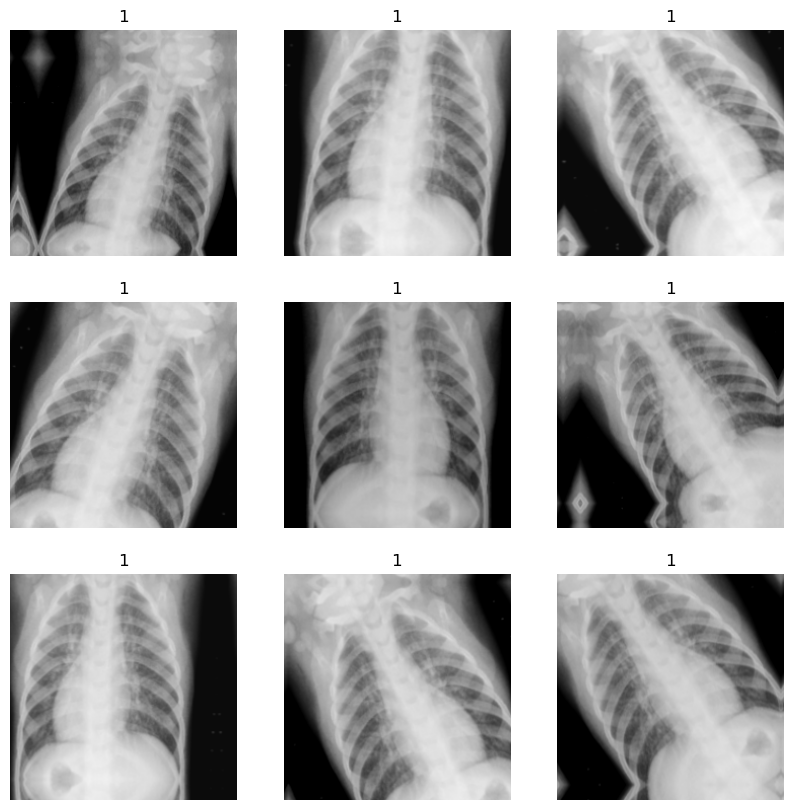

In [12]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.title(int(labels[0]))
        plt.axis("off")

### Building the Convolutional Neural Network (CNN)

In this step, we constructed a CNN model for binary classification using the following layers:

1. **Input Layer**:
    - Defined the input shape as `(img_width, img_height, 3)` to accept RGB images of size 224x224.

2. **Data Augmentation**:
    - Applied the `data_augmentation` pipeline to the input images to enhance the dataset by generating variations of the images.

3. **Rescaling**:
    - Normalized pixel values to the range `[0, 1]` by dividing by 255 using `layers.Rescaling(1./255)`.

4. **Convolutional and Pooling Layers**:
    - Added four convolutional layers with increasing filter sizes (32, 64, 128, 256) and kernel size `(3,3)`, each followed by a ReLU activation function.
    - Each convolutional layer is followed by a max-pooling layer with a pool size of `(2,2)` to reduce spatial dimensions.

5. **Flattening**:
    - Flattened the output of the last pooling layer into a 1D vector using `layers.Flatten()`.

6. **Dropout**:
    - Added a dropout layer with a rate of 0.5 to prevent overfitting by randomly deactivating 50% of the neurons during training.

7. **Output Layer**:
    - Added a dense layer with a single neuron and a sigmoid activation function to output probabilities for binary classification.

8. **Model Creation**:
    - Combined the input and output layers into a functional model using `keras.Model(inputs, outputs)`.

9. **Model Summary**:
    - Displayed the architecture of the model, including the number of parameters in each layer.

This architecture is designed to extract hierarchical features from the input images and classify them into two categories (e.g., NORMAL and PNEUMONIA). 

In [13]:
inputs = layers.Input(shape=(img_width, img_height, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(32, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(128, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(256, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

model.summary()


Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        36,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,281 (1.62 MB)

 Trainable params: 425,281 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the Model and Setting Up Callbacks

In this step, we compile the model with the following configurations:
- **Loss Function**: `binary_crossentropy` is used as the loss function since this is a binary classification problem.
- **Optimizer**: `adam` optimizer is chosen for its efficiency and adaptability.
- **Metrics**: We track `accuracy` to evaluate the model's performance during training.

Additionally, we define two callbacks to enhance the training process:
1. **ModelCheckpoint**: Saves the model with the best validation loss during training to avoid overfitting.
2. **EarlyStopping**: Stops training early if the validation loss does not improve for 5 consecutive epochs, preventing unnecessary computation.

In [39]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=["accuracy"])

callbacks = [keras.callbacks.ModelCheckpoint(
    filepath = "convnet_from_scratch_with_augmentation.keras",
    save_best_only = True,
    monitor = "val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        verbose=1
    )
]

history = model.fit(train_dataset, epochs=40, validation_data=val_dataset, callbacks=callbacks)

Epoch 1/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 183ms/step - accuracy: 0.7541 - loss: 0.5870 - val_accuracy: 0.5000 - val_loss: 0.7404
Epoch 2/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 181ms/step - accuracy: 0.7770 - loss: 0.5049 - val_accuracy: 0.8125 - val_loss: 0.4515
Epoch 3/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 182ms/step - accuracy: 0.8588 - loss: 0.3437 - val_accuracy: 0.8125 - val_loss: 0.3700
Epoch 4/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 184ms/step - accuracy: 0.8985 - loss: 0.2403 - val_accuracy: 0.9375 - val_loss: 0.2603
Epoch 5/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 179ms/step - accuracy: 0.9187 - loss: 0.2064 - val_accuracy: 0.6875 - val_loss: 0.6376
Epoch 6/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 184ms/step - accuracy: 0.9208 - loss: 0.1930 - val_accuracy: 0.7500 - val_loss: 0.5021
Epoch 7/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 181ms/step - accuracy: 0.9245 - loss: 0.1847 - val_accuracy: 0.7500 - val_loss: 0.5057
Epoch 8/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 183ms/step - accuracy: 0.9153 - loss: 0

### Plotting Training and Validation Metrics

In this section, we visualize the training and validation accuracy and loss over the epochs. This helps us understand how well the model is learning and whether it is overfitting or underfitting.

- **Accuracy Plot**: Shows the training and validation accuracy for each epoch.
- **Loss Plot**: Displays the training and validation loss for each epoch.

These plots provide insights into the model's performance and guide further tuning or adjustments.

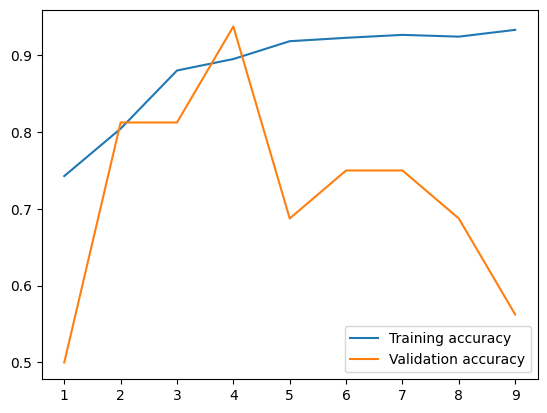

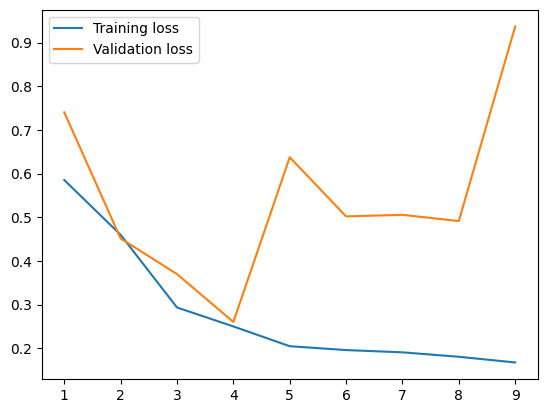

In [40]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = list(range(1, len(accuracy)+1))
plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.legend()
plt.show()

### Evaluating the Trained Model on the Test Dataset

In this step, we are loading the trained model (`convnet_from_scratch_with_augmentation.keras`) and evaluating its performance on the test dataset. The `evaluate` method is used to calculate the test loss and accuracy, which are printed to assess the model's generalization capability on unseen data.

In [41]:
test_model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8613 - loss: 0.3130
Test accuracy: 0.8477563858032227


### Visualizing Model Predictions on Test Data


In this section, we are evaluating the trained model on the test dataset and visualizing its predictions:

1. **Model Evaluation**: 
    - We load the trained model (`convnet_from_scratch_with_augmentation.keras`) and evaluate its performance on the test dataset using the `evaluate` method. 
    - The test loss and accuracy are printed to assess the model's performance.

2. **Prediction Visualization**:
    - We take a batch of images and labels from the test dataset.
    - The model predicts the class probabilities for these images.
    - The predicted classes are determined by taking the index of the maximum probability for each prediction.
    - For each image in the batch (up to a maximum of 16 images), we:
      - Display the image using `matplotlib`.
      - Show the true label and predicted label in the title of the subplot.
      - Use green text if the prediction is correct and red text if it is incorrect.
    - This visualization helps us understand how well the model performs on individual test samples.

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8613 - loss: 0.3130
Test Loss: 0.330
Test Accuracy: 0.848
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


/var/folders/dv/dz_58yk10xx8p5kdj0smcplc0000gn/T/ipykernel_60564/4102542593.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = class_names[int(labels[i])]  # Convert labels[i] to an integer
2025-05-08 19:42:14.245786: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


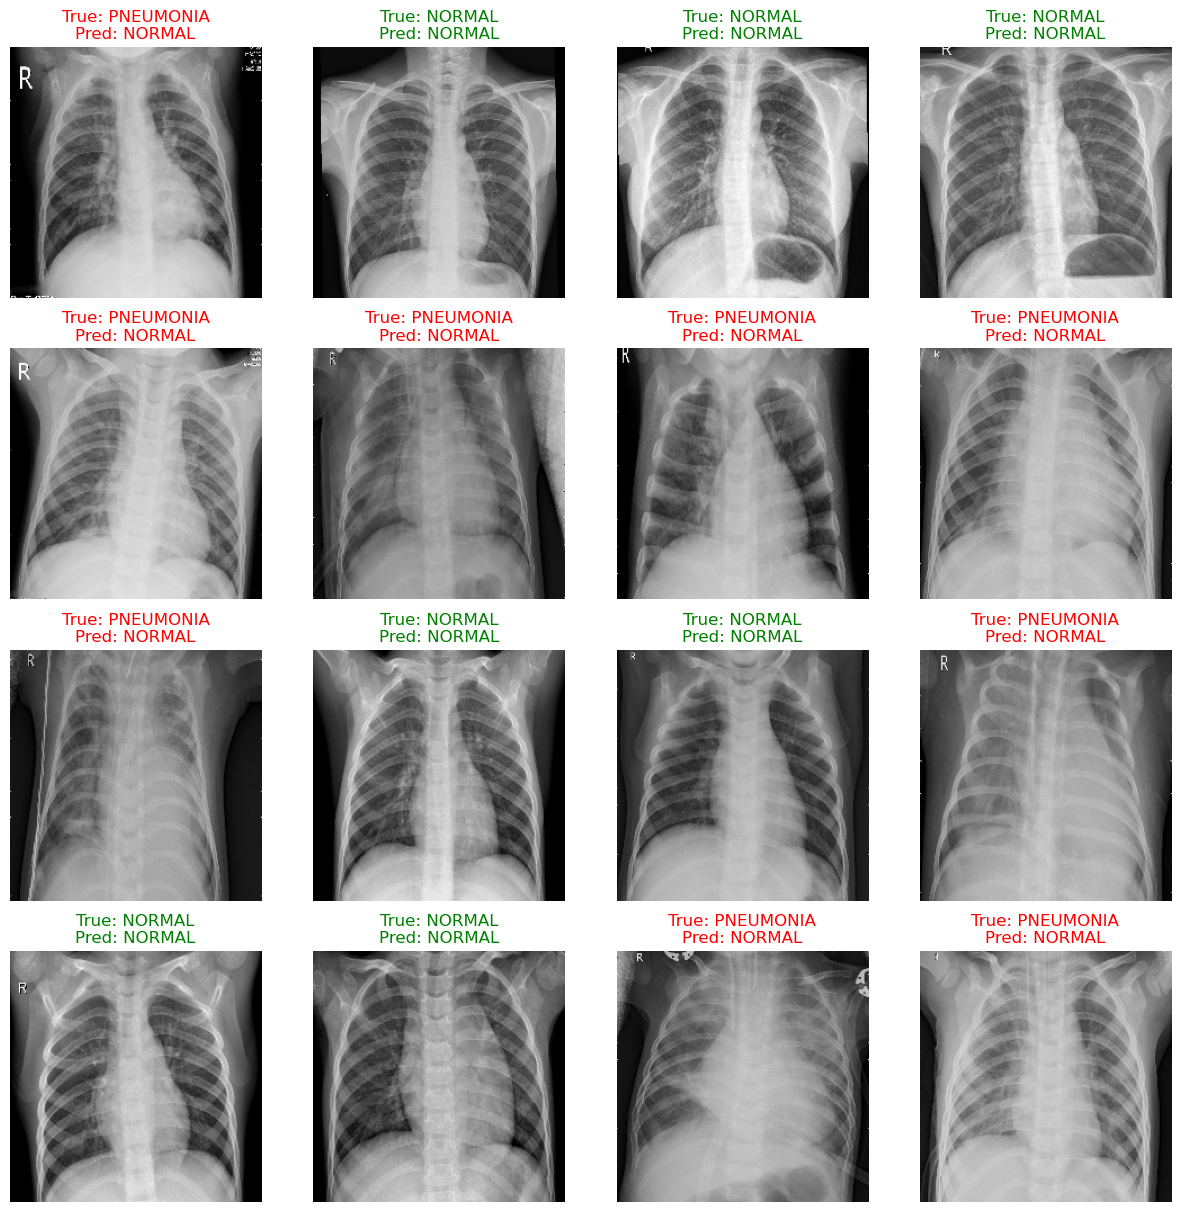

In [5]:
import matplotlib.pyplot as plt
import numpy as np


test_model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")

test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

class_names = test_dataset.class_names

plt.figure(figsize=(15, 15))
max_images = 16
for images, labels in test_dataset.take(1): 
    predictions = test_model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    labels = labels.numpy()  # Convert labels to a NumPy array
    for i in range(min(len(images), max_images)):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = class_names[int(labels[i])]  # Convert labels[i] to an integer
        predicted_label = class_names[predicted_classes[i]]
        color = "green" if predicted_label == true_label else "red"
        plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
        plt.axis("off")
plt.show()

### Final Thoughts and Conclusion

The Pneumonia-CNN project demonstrates the potential of deep learning in medical imaging for early detection of pneumonia. Below is a summary of the key steps and outcomes:

1. **Objective**:
    - The primary goal was to develop a Convolutional Neural Network (CNN) to classify chest X-ray images into NORMAL and PNEUMONIA categories, enabling early diagnosis and timely treatment.

2. **Data Preparation**:
    - The dataset was sourced from Kaggle and split into training, validation, and test sets.
    - Images were resized to `(224, 224)` and labeled for binary classification.

3. **Data Augmentation**:
    - A data augmentation pipeline was implemented to improve the model's generalization by applying transformations such as flipping, rotation, zooming, and brightness adjustments.

4. **Model Architecture**:
    - A CNN model was built with multiple convolutional and pooling layers, followed by a dropout layer to prevent overfitting.
    - The model was designed to extract hierarchical features and classify images with a sigmoid activation function in the output layer.

5. **Training and Optimization**:
    - The model was compiled with the `binary_crossentropy` loss function and the `adam` optimizer.
    - Callbacks such as `ModelCheckpoint` and `EarlyStopping` were used to save the best model and prevent overfitting.

6. **Evaluation**:
    - The model achieved a high accuracy on the test dataset, demonstrating its effectiveness in classifying chest X-ray images.
    - Visualization of predictions provided insights into the model's performance on individual samples.

7. **Future Improvements**:
    - Incorporating transfer learning with pre-trained models like MobileNetV2 could further enhance accuracy and efficiency.
    - Expanding the dataset and exploring additional augmentation techniques may improve robustness.

This project highlights the importance of leveraging deep learning for healthcare applications, showcasing its potential to assist medical professionals in diagnosing diseases more accurately and efficiently.